# **MODULE 1: PROGRAMMING AND BASIC STATISTICS**

## **Description**

This module introduces programming principles for data handling in Python. It also examines several tools for exploratory data analysis in support of informed decision-making.


In [1]:
# @title Environment setup
from pathlib import Path
import os
import subprocess
import sys


def find_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]
    for base in search_roots:
        candidates = [
            base / 'workshops' / '04-data-processing' / 'curso_IA_CHEC' / 'Modulo1' / 'databases',
            base / 'curso_IA_CHEC' / 'Modulo1' / 'databases',
            base / 'Modulo1' / 'databases',
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate
    raise FileNotFoundError('Could not find the Modulo1/databases directory in the current repository.')


if 'google.colab' in sys.modules:
    repo_root = Path('/content/curso_IA_CHEC')
    if not repo_root.exists():
        subprocess.run(
            ['git', 'clone', 'https://github.com/UN-GCPDS/curso_IA_CHEC.git', str(repo_root)],
            check=True,
        )
    os.chdir(repo_root)

DATA_DIR = find_data_dir()


def data_path(filename: str) -> Path:
    return DATA_DIR / filename


print(f'Using data from: {DATA_DIR}')


Using data from: /home/mitin/code/ml-theory/workshops/04-data-processing/curso_IA_CHEC/Modulo1/databases


# **Session 1**

In this session, we will learn how to work with data in pandas by using a [California housing prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) dataset as an example. Our focus will be on exploring the dataset through key functions such as `.head()`, `.info()`, and `.value_counts()`, among others.


## **Importing Libraries**
The first step is to import the required libraries.


In [2]:
import pandas as pd     # data manipulation and analysis
import numpy as np      # multidimensional arrays together with mathematical functions
import sqlite3          # interaction with SQLite databases
import ipywidgets as widgets  # interactive controls
from ipywidgets import interact  # interactive controls


## **Importing and Exporting Datasets in Different Formats**

We now load the data that will be used throughout this exercise. The most common data formats include:
- **CSV (Comma-Separated Values):** A simple text format in which data are organized into rows and columns separated by commas. It is widely used for data exchange across applications, especially spreadsheets and databases.

- **JSON (JavaScript Object Notation):** A structured data format that organizes information as key-value pairs. It is readable by both humans and machines, and it is commonly used in APIs (Application Programming Interfaces) and web applications.

- **SQL (Structured Query Language):** Strictly speaking, this is not a file format, but rather the language used to interact with relational databases. Data are stored in tables within a database and accessed through SQL queries.

- **Excel (XLSX/XLS):** A file format used by Microsoft Excel to store spreadsheet data. It supports tabular data, charts, formulas, filters, and more elaborate formatting.

For manipulating data in tabular form, the most widely used Python library is **`pandas`**. It provides functions for reading and writing tabular data in all of the formats listed above.

The principal parameters of this function are:
- **`filepath_or_buffer`**: Path or URL to the CSV file.
- **`sep`**: Field separator, by default `','`.
- **`header`**: Row containing the column names (by default, the first row: `header=0`).
- **`names`**: List of column names to use if no header is present or if custom names are desired.
- **`index_col`**: Column(s) to use as the DataFrame index.
- **`usecols`**: Columns to read, specified either by name or by position.
- **`dtype`**: Data types to assign to the columns.
- **`na_values`**: Additional values to interpret as `NaN`.
- **`nrows`**: Number of rows to read.
- **`skiprows`**: Rows to skip at the beginning of the file.
- **`parse_dates`**: Column(s) to interpret as dates.

In most cases, the default values are adequate, so no modifications are necessary.
Analogously, **`pandas`** also provides functions for reading the other formats discussed above: [read_json()](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html), [read_sql()](https://pandas.pydata.org/docs/reference/api/pandas.read_sql.html), and [read_excel()](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html).


In [3]:
# Load the data in CSV format
housing = pd.read_csv(data_path('california_housing.csv'))


In addition, pandas includes functions for saving datasets in the formats discussed above. For example, to save data in CSV format, one may use the [DataFrame.to_csv()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) method, whose main parameters are:
- **`path_or_buf`**: Path or buffer to which the CSV file will be written. If omitted, the method returns the CSV as a string.
- **`sep`**: Field separator, by default `','`.
- **`index`**: Whether to include the DataFrame index (by default `True`).
- **`header`**: Whether to include the column names (by default `True`).
- **`columns`**: List of columns to export.
- **`na_rep`**: Representation of `NaN` values (by default, they are left blank).
- **`float_format`**: Output format for floating-point values.
- **`date_format`**: Output format for date columns.
- **`encoding`**: Encoding of the resulting file (for example, `'utf-8'`).
- **`line_terminator`**: Characters used to terminate lines (by default `"
"`).

Likewise, pandas provides methods for saving data in JSON ([DataFrame.to_json()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_json.html)), SQL ([DataFrame.to_sql()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_sql.html)), and Excel ([DataFrame.to_excel()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html)) formats.

For illustration, we will now save the dataset we just read in these additional formats.


In [4]:
# housing.to_csv(data_path('california_housing.csv'), index=False)
housing.to_json(data_path('california_housing.json'))
housing.to_excel(data_path('california_housing.xlsx'), index=False)


In [5]:
# To save the data in SQL format, we first create the database and connect to it
# by using the sqlite3 library.
conn = sqlite3.connect(data_path('california_housing.db'))
# The to_sql method takes the table name as its first argument and the
# database connection as its second argument.
housing.to_sql('housing', conn, if_exists='replace', index=False)
conn.close()


We now proceed to read these files.


In [6]:
housing_json = pd.read_json(data_path('california_housing.json'))
housing_excel = pd.read_excel(data_path('california_housing.xlsx'))
conn = sqlite3.connect(data_path('california_housing.db'))
housing_sql = pd.read_sql("SELECT * FROM housing", conn)
conn.close()


If we inspect `housing_json`, `housing_excel`, and `housing_sql`, we can see that all three are equivalent to `housing`. Since the remainder of this session will continue using only the original `housing` DataFrame, we may safely remove the additional copies from memory.


In [7]:
del housing_json, housing_excel, housing_sql

## **Initial Exploration of the Dataset with `.head()`**

The `.head()` function allows us to view the first rows of a dataset, which provides a rapid and general first look at its structure and contents. This is particularly useful when beginning an analysis, because it helps identify the nature of the columns and the overall quality of the data.


In [8]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing.shape

(20640, 10)

You may adjust the number 5 to any positive integer in order to display more or fewer rows as needed. Below, you may also choose how many rows you would like to display in the table.


In [10]:
@interact(x=(0, 100, 1))
def update_view(x=5):
    # The display function allows the table to be rendered when
    # .head() is used inside a function.
    display(housing.head(x))


interactive(children=(IntSlider(value=5, description='x'), Output()), _dom_classes=('widget-interact',))

## **General Information about the Dataset with `.info()`**

The `.info()` function provides a summary of the dataset, including the number of entries, the data types of each column, and the quantity of missing values. This is very useful for understanding the structure of the data and identifying potential quality issues, such as missing observations.


In [11]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## **Frequency Analysis with `.value_counts()`**

The `.value_counts()` function is useful for analyzing the frequency of the values in a specific column. For example, it allows us to determine how often each value appears. Below, we illustrate this analysis for `ocean_proximity`.


In [12]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

This result tells us that the most common ocean-proximity category is **<1H OCEAN**. You may replace `ocean_proximity` with any other column. Below, you may select a column and display its 10 most frequent values.


In [13]:
# @title Frequency analysis widget
def on_column_change(change):
    column = change if isinstance(change, str) else change.new
    value_counts = housing[column].value_counts()
    # Restrict the output to the first 10 counts.
    limited_counts = value_counts.head(10)
    # Convert the counts to HTML so that they can be displayed in the widget.
    result_label.value = limited_counts.to_frame().to_html(classes='table table-striped', border=0)


# Create a dropdown menu with the column names.
column_dropdown = widgets.Dropdown(
    options=housing.columns,
    value=housing.columns[0],
    description='Column:',
)

# Create an HTML widget to display the result.
result_label = widgets.HTML(value='')

on_column_change(column_dropdown.value)
# Bind the function to dropdown-value changes.
column_dropdown.observe(on_column_change, names='value')

# Display the dropdown menu and the result widget.
display(column_dropdown, result_label)


Dropdown(description='Column:', options=('longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_…

HTML(value='<table class="dataframe table table-striped">\n  <thead>\n    <tr style="text-align: right;">\n   …

In [14]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## **Basic Indexing**


* We may view only the columns of interest by specifying them directly in the DataFrame.


In [15]:
housing[housing['total_rooms']==39320]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13139,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,153700.0,INLAND


In [16]:
housing[['population', 'median_house_value']]

,population,median_house_value
0,322.0,452600.0
1,2401.0,358500.0
2,496.0,352100.0
3,558.0,341300.0
4,565.0,342200.0
...,...,...
20635,845.0,78100.0
20636,356.0,77100.0
20637,1007.0,92300.0
20638,741.0,84700.0


In [17]:
print('Select the columns you would like to visualize.')

# Create checkboxes for selecting columns.
checkboxes = [widgets.Checkbox(value=False, description=col) for col in housing.columns]

# Create an output area to display the DataFrame.
output_area = widgets.Output()


# Display the selected columns.
def show_columns(_):
    with output_area:
        # Clear the output area.
        output_area.clear_output()
        # Gather the selected columns.
        selected_columns = [col.description for col in checkboxes if col.value]
        if selected_columns:
            display(housing[selected_columns])
        else:
            print('Select at least one column in order to display the DataFrame.')


# Create a button to refresh the selection.
update_button = widgets.Button(description='Update selection')
update_button.on_click(show_columns)

# Display the checkboxes and button.
display(*checkboxes)
display(update_button)

# Display the output area.
display(output_area)


Select the columns you would like to visualize.


Checkbox(value=False, description='longitude')

Checkbox(value=False, description='latitude')

Checkbox(value=False, description='housing_median_age')

Checkbox(value=False, description='total_rooms')

...

Checkbox(value=False, description='median_income')

Checkbox(value=False, description='median_house_value')

Checkbox(value=False, description='ocean_proximity')

Button(description='Update selection', style=ButtonStyle())

Output()

* `.index` provides the index labels of the DataFrame.

  A DataFrame index is a sequence of labels that identifies each row. The labels may be integers, strings, or any other hashable type. The index is used for label-based access and alignment, and it can be inspected or modified through this attribute.


In [18]:
housing.index

RangeIndex(start=0, stop=20640, step=1)

In this case, each entry (row) is identified by an integer index ranging from 0 to 20639.


In [19]:
housing.index[0]  # the index of element 0 is 0


0

In [20]:
housing.index[455]  # the index of element 455 is 455


455

* `.loc` allows us to select specific rows and/or specific samples.

  For example, to select rows 0, 4, and 5:


In [21]:
housing.loc[[0,4,5]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY


In addition, we may decide which columns should be displayed for the selected rows. For example, let us display only the columns that contain the geographic position (`longitude` and `latitude`).


In [22]:
housing.loc[[0,4,5],['longitude', 'latitude']]

,longitude,latitude
0,-122.23,37.88
4,-122.25,37.85
5,-122.25,37.85


In [23]:
# @title View selected columns

print('Select the columns you would like to inspect from these data.')

# Create checkboxes for selecting columns.
checkboxes = [widgets.Checkbox(value=False, description=col) for col in housing.columns]

# Create an output area to display the DataFrame.
output_area = widgets.Output()


# Display the selected columns.
def show_columns(_):
    with output_area:
        # Clear the output area.
        output_area.clear_output()
        # Gather the selected columns.
        selected_columns = [col.description for col in checkboxes if col.value]
        if selected_columns:
            display(housing.loc[[0, 4, 5], selected_columns])
        else:
            display('Select at least one column in order to display the DataFrame.')


# Create a button to refresh the selection.
update_button = widgets.Button(description='Update selection')
update_button.on_click(show_columns)

# Display the checkboxes and button.
display(*checkboxes)
display(update_button)

# Display the output area.
display(output_area)


Select the columns you would like to inspect from these data.


Checkbox(value=False, description='longitude')

Checkbox(value=False, description='latitude')

Checkbox(value=False, description='housing_median_age')

Checkbox(value=False, description='total_rooms')

...

Checkbox(value=False, description='median_income')

Checkbox(value=False, description='median_house_value')

Checkbox(value=False, description='ocean_proximity')

Button(description='Update selection', style=ButtonStyle())

Output()

Pandas also provides `.iloc`, which operates like `.loc` but uses positional indices rather than the DataFrame's index labels and column names.


## **Basic Statistical Analysis**

* `.describe()` produces basic descriptive statistics for the variables (columns). Descriptive statistics summarize the central tendency, dispersion, and distributional shape of a dataset while excluding missing values.

These quantities are defined as follows:

1. **count:** the number of non-missing observations in the column.

2. **mean:** the arithmetic mean is a measure of central tendency obtained by summing all values in the dataset and dividing by the number of observations.
$$ar{x} = 
rac{\sum_{i=1}^{n} x_i}{n}$$
where:
- $x_i$ denotes each individual value.
- $n$ denotes the total number of values.

3. **std (standard deviation):** the standard deviation measures the dispersion of the data relative to the mean.

  Sample variance:
  $$
  s^2 = 
rac{\sum_{i=1}^{n} (x_i - ar{x})^2}{n - 1}
  $$
  Population variance:
  $$
  \sigma^2 = 
rac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}
  $$
  where:
  - $x_i$ denotes each value.
  - $ar{x}$ denotes the sample mean.
  - $\mu$ denotes the population mean.
  - $n$ denotes the sample size.
  - $N$ denotes the population size.

4. **min:** the smallest observed value in the column.

5. **25% (first quartile):** 25% of the observations lie below this value, marking the lower quartile of the distribution.

6. **50% (median or second quartile):** the central value of the distribution, below which 50% of the observations lie.

7. **75% (third quartile):** 75% of the observations lie below this value, marking the upper quartile of the bulk of the data.

8. **max:** the largest observed value in the column.


Select the column whose basic descriptive statistics you would like to inspect.


In [24]:
# @title Statistical analysis
# Display the descriptive statistics for the selected column.
def on_column_change(change):
    column = change.new
    if column in housing.columns:
        statistics = housing[column].describe()

        # Convert the descriptive statistics to HTML for widget display.
        result_label.value = statistics.to_frame().to_html(classes='table table-striped', border=0)
    else:
        result_label.value = 'Invalid column'


# Create a dropdown menu with the column names.
column_dropdown = widgets.Dropdown(
    options=housing.columns,
    value=housing.columns[0],
    description='Column:',
)

# Create an HTML widget to display the result.
result_label = widgets.HTML(value='')

# Bind the function to dropdown-value changes.
column_dropdown.observe(on_column_change, names='value')

# Display the dropdown menu and the result widget.
display(column_dropdown, result_label)


Dropdown(description='Column:', options=('longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_…

HTML(value='')

* `.cov()`: covariance measures how two variables vary together.

  Sample covariance:
$$
	ext{Cov}(X, Y) = 
rac{\sum_{i=1}^{n} (x_i - ar{x})(y_i - ar{y})}{n - 1}
$$

  Population covariance:
$$
	ext{Cov}(X, Y) = 
rac{\sum_{i=1}^{N} (x_i - \mu_x)(y_i - \mu_y)}{N}
$$

  where:
  - $x_i$ and $y_i$ denote the values of variables $X$ and $Y$.
  - $ar{x}$ and $ar{y}$ denote the sample means of $X$ and $Y$.
  - $\mu_x$ and $\mu_y$ denote the population means of $X$ and $Y$.
  - $n$ denotes the sample size.
  - $N$ denotes the population size.


In [25]:
housing_numerico = housing.iloc[:,:-1]
cov_matrix = housing_numerico.cov()
cov_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,4.014139,-3.957054,-2.728244,1.948037e+02,5.876851e+01,2.263778e+02,4.236807e+01,-0.057765,-1.062743e+04
latitude,-3.957054,4.562293,0.300346,-1.682178e+02,-6.029962e+01,-2.631378e+02,-5.801024e+01,-0.323860,-3.553256e+04
housing_median_age,-2.728244,0.300346,158.396260,-9.919120e+03,-1.700313e+03,-4.222271e+03,-1.457581e+03,-2.846140,1.533988e+05
total_rooms,194.803750,-168.217847,-9919.120060,4.759445e+06,8.567306e+05,2.117613e+06,7.661046e+05,820.852410,3.377289e+07
total_bedrooms,58.768508,-60.299623,-1700.312817,8.567306e+05,1.775654e+05,4.191391e+05,1.578295e+05,-6.180851,2.416878e+06
population,226.377839,-263.137814,-4222.270582,2.117613e+06,4.191391e+05,1.282470e+06,3.928036e+05,10.400979,-3.221249e+06
households,42.368072,-58.010245,-1457.581290,7.661046e+05,1.578295e+05,3.928036e+05,1.461760e+05,9.466667,2.904924e+06
median_income,-0.057765,-0.323860,-2.846140,8.208524e+02,-6.180851e+00,1.040098e+01,9.466667e+00,3.609323,1.508475e+05
median_house_value,-10627.425205,-35532.559074,153398.801329,3.377289e+07,2.416878e+06,-3.221249e+06,2.904924e+06,150847.482793,1.331615e+10


* `.corr()`: correlation is a normalized version of covariance that measures both the direction and the strength of the relationship between two variables. Correlation always lies in the interval from -1 to 1, which makes interpretation easier.

  $$
  
ho_{XY} = 
rac{	ext{Cov}(X, Y)}{\sigma_X \sigma_Y}
  $$
  where:
  - $\sigma_X$ and $\sigma_Y$ denote the standard deviations of $X$ and $Y$.


In [26]:
corr_matrix = housing_numerico.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


To obtain a visual representation of the correlation matrix, we may use a heat map.


<Axes: >

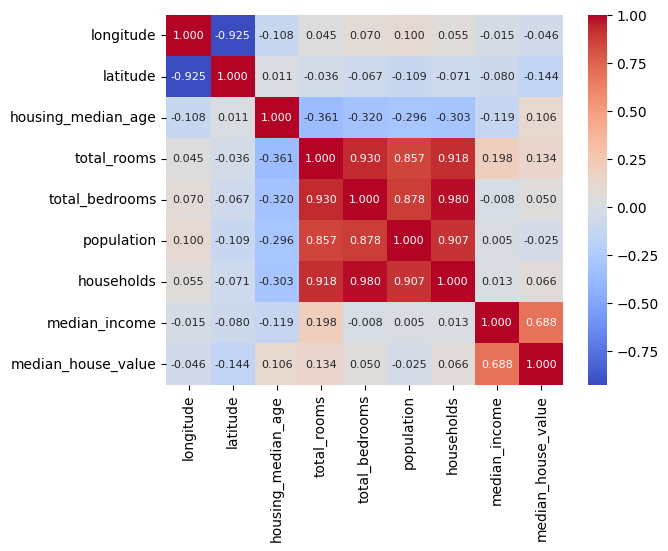

In [27]:
import seaborn as sns  # Import seaborn, a library used for statistical graphics.

# Create a heat map of the correlation matrix by using seaborn.heatmap.
# The x-axis and y-axis labels are set equal to the column names of the correlation matrix.
sns.heatmap(corr_matrix,
            xticklabels=corr_matrix.columns.values,  # x-axis labels
            yticklabels=corr_matrix.columns.values,  # y-axis labels
            cmap='coolwarm',  # color palette
            annot=True,  # display the value in each cell
            fmt='.3f',  # round values to three decimal places
            annot_kws={'size': 8})  # annotation font size


In [28]:
# Compute the correlation matrix R.
Rh = housing_numerico.corr()
# Initialize the partial-correlation matrix with the same size as R,
# excluding the row and column associated with median_house_value.
R_parcial = pd.DataFrame(np.zeros((Rh.shape[0] - 1, Rh.shape[1] - 1)),
                         columns=Rh.columns[:-1], index=Rh.columns[:-1])
# Fix the z iterator at the last column.
iz = -1
# Iterate over the remaining columns.
for ix in range(len(housing_numerico.columns) - 1):
    for iy in range(ix + 1, len(housing_numerico.columns) - 1):
        R_xy = Rh.iloc[ix, iy]
        R_xz = Rh.iloc[ix, iz]
        R_yz = Rh.iloc[iy, iz]
        # Compute the partial correlation.
        pcorr = (R_xy - R_xz * R_yz) / np.sqrt((1 - R_xz**2) * (1 - R_yz**2))
        # Store the resulting value in the corresponding entry of the
        # partial-correlation matrix.
        R_parcial.iloc[ix, iy] = pcorr

# Only the upper triangular part was computed above, since the matrix is symmetric.
R_parcial += R_parcial.T
R_parcial.iloc[np.arange(len(R_parcial)), np.arange(len(R_parcial))] = 1


<Axes: >

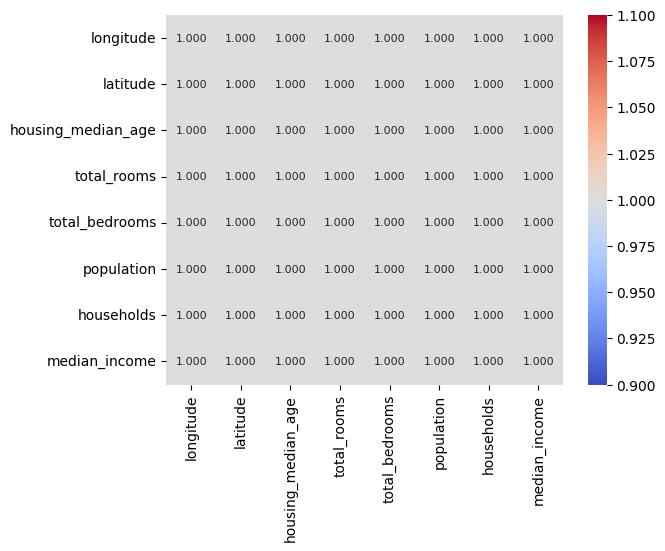

In [29]:
sns.heatmap(R_parcial,
            xticklabels=R_parcial.columns.values,  # x-axis labels
            yticklabels=R_parcial.columns.values,  # y-axis labels
            cmap='coolwarm',  # color palette
            annot=True,  # display the value in each cell
            fmt='.3f',  # round values to three decimal places
            annot_kws={'size': 8})  # annotation font size


## **Data Imputation**
Previously, we observed that the `total_bedrooms` column contains several missing values. This situation can be problematic for later analyses or predictive models built from the data. For that reason, it is important to replace missing values with reasonable estimates. This process is known as data imputation.

A common technique is to use a measure of central tendency such as the mean, median, or mode. However, the appropriate choice depends on several factors related to the nature and amount of missing data.

Let us examine how imputation can be carried out in this dataset by using the mean and the `.fillna()` method.


In [30]:
# inplace=True modifies the housing DataFrame directly.
# Load the data in CSV format.
# housing = pd.read_csv('Modulo1/databases/california_housing.csv')
# housing['total_bedrooms'].fillna(, inplace=True)


In [31]:
housing['total_bedrooms'].mean()

np.float64(537.8705525375618)

In [32]:
#537.870553,597.113566,532.486240,536.838857,535.284351
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## In-Class Exercise: Developing a Regressor on a Real Dataset

Let us conclude by applying our knowledge to the **Housing** dataset, a classical example in regression analysis. This dataset contains information about the housing market across different California districts, with the goal of **predicting the median house value** from several explanatory variables.

The dataset includes multiple features for each district, such as:

1. Crime-related and demographic context.
2. Residential land-use proportions.
3. Average room counts per dwelling.
4. Median housing age.
5. Distance-related geographic attributes.

The objective is to construct a model capable of predicting the median value of houses from these variables. This is where everything learned about linear regression becomes relevant, while still allowing us to explore **nonlinear models** as well.


**longitude**: Geographic longitude of the housing area.

**latitude**: Geographic latitude of the housing area.

**housing_median_age**: Median age of the houses in the area.

**total_rooms**: Total number of rooms across all houses in the area.

**total_bedrooms**: Total number of rooms used as bedrooms in the area.

**population**: Total number of residents in the area.

**households**: Total number of housing units in the area.

**median_income**: Median income of the residents (in tens of thousands of dollars).

**median_house_value**: Median house value (in dollars).

**ocean_proximity**: Proximity to the ocean (categorical variable).


**ocean_proximity**: Proximity to the ocean (categorical variable).

- **NEAR BAY**: Near the bay.  
- **NEAR OCEAN**: Near the ocean.  
- **INLAND**: Inland.  
- **<1H OCEAN**: Less than one hour from the ocean.  
- **ISLAND**: Island.  


In [33]:
# @title Data exploration
import os
import pandas as pd
import zipfile
import gdown
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt

# Google Drive file ID
FILEID = '1sa_cmQVPlMsL6i0Pk7w3lwJRm6_8Peoj'
ZIP_FILE = 'codigos.zip'
DATA_FOLDER = 'datasets/housing'
CSV_FILE = os.path.join(DATA_FOLDER, 'housing.csv')


# Download and extract the archive if it is not already available.
def download_and_extract():
    if not os.path.exists(CSV_FILE):
        print('File not found locally; downloading...')

        # Google Drive download URL
        url = f'https://drive.google.com/uc?export=download&id={FILEID}'

        # Download with gdown
        gdown.download(url, ZIP_FILE, quiet=False)

        # Extract the archive
        with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
            zip_ref.extractall('.')
        print('File downloaded and extracted.')
    else:
        print('File already exists locally.')


# Verify or download the file.
download_and_extract()

# Read the CSV file.
housing = pd.read_csv(CSV_FILE)


# Explore the data interactively.
def explore_data(info_type):
    if info_type == 'Head':
        display(housing.head())
    elif info_type == 'Description':
        display(housing.describe())
    elif info_type == 'Information':
        display(housing.info())
    elif info_type == 'Missing Values':
        display(housing.isnull().sum())
    elif info_type == 'Attribute Distributions':
        housing.hist(bins=50, figsize=(20, 15))
        plt.show()
    else:
        print('Invalid option.')


# Interactive menu for selecting the information to explore.
interact(explore_data,
         info_type=Dropdown(options=['Head', 'Description', 'Information', 'Missing Values', 'Attribute Distributions'],
                            value='Head', description='View:'));


File already exists locally.


interactive(children=(Dropdown(description='View:', options=('Head', 'Description', 'Information', 'Missing Va…

**Let us continue.** We now address a common challenge in data cleaning: **missing values**. When working with real-world data, it is very common to encounter rows or columns that contain empty entries. This may occur for many reasons, such as data-entry errors or the absence of information in certain records.

There are several strategies for handling missing values. Below, we review the principal options together with their main advantages and disadvantages.

### 1. **Delete rows or columns with missing values**
   - **Advantages**: This is a simple and direct strategy, useful when the number of missing values is small and does not represent a large proportion of the data.
   - **Disadvantages**: If many values are missing, removing too many rows or columns can significantly reduce the size of the dataset and lead to the loss of important information.

### 2. **Fill missing values with a constant**
   - **Advantages**: This technique is useful when one wishes to preserve the structure of the dataset without dropping rows or columns. A constant such as 0 or the mean may be used as a replacement.
   - **Disadvantages**: Using a constant may introduce bias when the missing values are not random. It may also distort the distribution of the data.

### 3. **Fill with the mean or median** (`SimpleImputer` from `sklearn`)
   - **Advantages**: Filling with the **mean** (for numerical data) or the **median** is a common strategy that preserves the size of the dataset and avoids discarding information. It is especially useful when the missing values do not follow a clear pattern.
   - **Disadvantages**: This method may smooth out the natural variability of the data. If many values are missing, the mean or median may fail to reflect the structure of the dataset adequately.

### 4. **Fill with the most frequent value** (`SimpleImputer` with `strategy='most_frequent'`)
   - **Advantages**: This works well for categorical data. It preserves consistency by replacing missing values with the most common category.
   - **Disadvantages**: If the data are imbalanced, this approach may reinforce bias toward the dominant category.

### 5. **Fill by interpolation or predictive models** (`KNNImputer` or `IterativeImputer`)
   - **Advantages**: By using more advanced techniques, such as **interpolation** or **nearest neighbors (KNN)**, one can predict missing values from other values in the dataset. This often produces better results when the amount of missing data is substantial or when the missingness follows a more complex pattern.
   - **Disadvantages**: These methods are slower and computationally more expensive. They may also introduce unnecessary complexity when the data do not exhibit relationships that can be modeled reliably.

---

In summary, the most appropriate strategy depends on the nature of the data and on the proportion of missing values. If only a few values are missing, **deleting rows** may be sufficient. If the data are continuous, **filling with the mean or median** may work well; for categorical data, **filling with the most frequent value** is often a sound choice. If a more sophisticated approach is needed, **KNN** or **predictive models** may improve the quality of the imputation.

**Let us test these techniques on the dataset and compare the results.**


In [34]:
# @title Data cleaning
import numpy as np
import pandas as pd
from ipywidgets import interact, Dropdown
from sklearn.impute import SimpleImputer, KNNImputer


# Class responsible for handling the data and applying cleaning strategies.
class DataVisualizer:
    def __init__(self, data):
        self.original_data = data  # Store the original DataFrame.
        self.cleaned_data = data.copy()  # The cleaned version initially matches the original one.

    # Apply the selected strategy.
    def apply_strategy(self, strategy):
        if strategy == 'Drop Rows':
            self.cleaned_data = self.original_data.dropna()
        elif strategy == 'Fill with Constant (0)':
            imputer = SimpleImputer(strategy='constant', fill_value=0)
            self.cleaned_data = pd.DataFrame(imputer.fit_transform(self.original_data), columns=self.original_data.columns)
        elif strategy == 'Fill with Mean':
            imputer = SimpleImputer(strategy='mean')
            self.cleaned_data = pd.DataFrame(imputer.fit_transform(self.original_data.select_dtypes(include=np.number)), columns=self.original_data.select_dtypes(include=np.number).columns)
        elif strategy == 'Fill with Median':
            imputer = SimpleImputer(strategy='median')
            self.cleaned_data = pd.DataFrame(imputer.fit_transform(self.original_data.select_dtypes(include=np.number)), columns=self.original_data.select_dtypes(include=np.number).columns)
        elif strategy == 'Fill with Most Frequent Value':
            imputer = SimpleImputer(strategy='most_frequent')
            self.cleaned_data = pd.DataFrame(imputer.fit_transform(self.original_data), columns=self.original_data.columns)
        elif strategy == 'KNN Imputer':
            imputer = KNNImputer(n_neighbors=5)
            self.cleaned_data = pd.DataFrame(imputer.fit_transform(self.original_data.select_dtypes(include=np.number)), columns=self.original_data.select_dtypes(include=np.number).columns)
            self.cleaned_data['ocean_proximity'] = self.original_data['ocean_proximity'].values

        # Return the cleaned DataFrame.
        return self.cleaned_data

    # Show rows with missing values before and after imputation.
    def show_missing_values(self, strategy):
        missing_rows = self.original_data[self.original_data.isnull().any(axis=1)]

        if missing_rows.empty:
            print('There are no rows with missing values.')
        else:
            print('Missing values before imputation:\\n')
            display(missing_rows.head())

        cleaned_data = self.apply_strategy(strategy)

        if strategy == 'Drop Rows':
            print('\nRows containing missing values have been removed.')
        else:
            print(f"\nValues after applying '{strategy}':\n")
            existing_rows = cleaned_data.index.intersection(missing_rows.index)
            if not existing_rows.empty:
                display(cleaned_data.loc[existing_rows].head())
            else:
                print('The original rows containing missing values are no longer present.')


# Initialize the class with the loaded DataFrame (housing).
visualizer = DataVisualizer(housing)


# Interactive function for selecting the cleaning strategy.
def interactive_missing_values(strategy):
    visualizer.show_missing_values(strategy)


# Interactive selection of the cleaning strategy.
interact(interactive_missing_values,
         strategy=Dropdown(options=['Drop Rows',
                                    'Fill with Constant (0)',
                                    'Fill with Mean',
                                    'Fill with Median',
                                    'Fill with Most Frequent Value',
                                    'KNN Imputer'],
                           description='Strategy:', value='Drop Rows'));


interactive(children=(Dropdown(description='Strategy:', options=('Drop Rows', 'Fill with Constant (0)', 'Fill …

In [35]:
# @title Encoding categorical variables
import numpy as np
import pandas as pd
from ipywidgets import interact, Dropdown
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
cleaned_housing = visualizer.cleaned_data


# Class responsible for handling the data and applying encoding strategies.
class CategoricalEncodingVisualizer:
    def __init__(self, data):
        self.original_data = data  # Store the original DataFrame.
        self.categorical_cols = data.select_dtypes(include=['object']).columns  # Categorical columns.
        self.last_encoded_data = None  # Store the most recent encoded data.

    def apply_encoding(self, strategy):
        # Apply the selected encoding strategy and return an encoded copy.
        data_copy = self.original_data.copy()

        if not len(self.categorical_cols):
            print('There are no categorical columns in the data.')
            return data_copy

        if strategy == 'Ordinal Encoder':
            encoder = OrdinalEncoder()
            data_copy[self.categorical_cols] = encoder.fit_transform(data_copy[self.categorical_cols])
        elif strategy == 'One-Hot Encoder':
            encoder = OneHotEncoder(sparse_output=False)
            encoded_data = pd.DataFrame(
                encoder.fit_transform(data_copy[self.categorical_cols]),
                columns=encoder.get_feature_names_out(self.categorical_cols),
                index=data_copy.index,
            )
            data_copy = data_copy.drop(self.categorical_cols, axis=1)
            data_copy = pd.concat([data_copy, encoded_data], axis=1)
        else:
            raise ValueError(f'Unknown strategy: {strategy}')

        # Store the latest transformation.
        self.last_encoded_data = data_copy
        return data_copy

    def get_last_encoded_data(self):
        # Return the encoded data from the most recent transformation.
        if self.last_encoded_data is not None:
            return self.last_encoded_data
        print('No encoding has been applied yet.')
        return None

    def show_encoded_data(self, strategy):
        # Display a preview of the encoded data for the selected strategy.
        try:
            print(f"\nPreview of the encoded data using '{strategy}':\n")
            encoded_data = self.apply_encoding(strategy)
            display(encoded_data.head())
        except Exception as e:
            print(f"Error while applying strategy '{strategy}': {e}")


# Initialize the class with the cleaned DataFrame.
cleaned_housing = visualizer.cleaned_data
visualizer = CategoricalEncodingVisualizer(cleaned_housing)


# Interactive function for selecting the encoding strategy.
def interactive_encoding(strategy):
    visualizer.show_encoded_data(strategy)


# Interactive selection of the encoding strategy.
interact(interactive_encoding,
         strategy=Dropdown(options=['Ordinal Encoder',
                                    'One-Hot Encoder'],
                           description='Encoding Strategy:', value='Ordinal Encoder'));


/tmp/ipykernel_13646/2328683117.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  self.categorical_cols = data.select_dtypes(include=['object']).columns  # Categorical columns.


interactive(children=(Dropdown(description='Encoding Strategy:', options=('Ordinal Encoder', 'One-Hot Encoder'…

In [36]:
encoding_housing=visualizer.get_last_encoded_data()

In [37]:
# Display information about the cleaned dataset
encoding_housing.info(
)


<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  float64
dtypes: float64(10)
memory usage: 1.7 MB


In [38]:
import numpy as np
import pandas as pd
from ipywidgets import interact, Dropdown
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


# Class responsible for handling the data and applying scaling strategies.
class DataScalingVisualizer:
    def __init__(self, data):
        self.original_data = data  # Store the original DataFrame.
        self.numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns  # Numerical columns.
        self.last_scaled_data = None  # Store the most recent scaled data.

    def apply_scaling(self, strategy):
        # Apply the selected scaling strategy and return a scaled copy.
        data_copy = self.original_data.copy()

        if not len(self.numeric_cols):
            print('There are no numerical columns in the data.')
            return data_copy

        if strategy == 'Standard Scaler':
            scaler = StandardScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        elif strategy == 'MinMax Scaler':
            scaler = MinMaxScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        elif strategy == 'Robust Scaler':
            scaler = RobustScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        else:
            raise ValueError(f'Unknown strategy: {strategy}')

        # Store the latest transformation.
        self.last_scaled_data = data_copy
        return data_copy

    def get_last_scaled_data(self):
        # Return the scaled data from the most recent transformation.
        if self.last_scaled_data is not None:
            return self.last_scaled_data
        print('No scaling has been applied yet.')
        return None

    def show_scaled_data(self, strategy):
        # Display a preview of the scaled data for the selected strategy.
        try:
            print(f"\nPreview of the scaled data using '{strategy}':\n")
            scaled_data = self.apply_scaling(strategy)
            display(scaled_data.head())
        except Exception as e:
            print(f"Error while applying strategy '{strategy}': {e}")


# Initialize the class with the loaded DataFrame.
cleaned_housing = encoding_housing
scaler_visualizer = DataScalingVisualizer(cleaned_housing)


# Interactive function for selecting the scaling strategy.
def interactive_scaling(strategy):
    scaler_visualizer.show_scaled_data(strategy)


# Interactive selection of the scaling strategy.
interact(interactive_scaling,
         strategy=Dropdown(options=['Standard Scaler',
                                    'MinMax Scaler',
                                    'Robust Scaler'],
                           description='Scaling Strategy:', value='Standard Scaler'));


interactive(children=(Dropdown(description='Scaling Strategy:', options=('Standard Scaler', 'MinMax Scaler', '…

In [39]:
# @title Results of scaling the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


# Generate data with controlled distributions.
def generate_distribution(mean, std, size):
    return np.random.normal(loc=mean, scale=std, size=int(size))


# Visualize distributions and the effect of different scalers.
class ScalingDistributionVisualizer:
    def __init__(self):
        self.data1 = None
        self.data2 = None
        self.data_original1 = None
        self.data_original2 = None
        self.scalers = {
            'Standard Scaler': StandardScaler(),
            'MinMax Scaler': MinMaxScaler(),
            'Robust Scaler': RobustScaler()
        }

    def generate_data(self, mean1, std1, size1, mean2, std2, size2):
        # Generate two normal distributions from the given parameters.
        self.data_original1 = generate_distribution(mean1, std1, size1).reshape(-1, 1)
        self.data_original2 = generate_distribution(mean2, std2, size2).reshape(-1, 1)
        self.data1 = self.data_original1.copy()
        self.data2 = self.data_original2.copy()

    def apply_scaling(self, scaler_name1, scaler_name2):
        # Apply the selected scalers to the two generated distributions.
        if self.data1 is None or self.data2 is None:
            print('Please generate the data first.')
            return None, None

        scaler1 = self.scalers.get(scaler_name1)
        scaler2 = self.scalers.get(scaler_name2)

        if not scaler1 or not scaler2:
            raise ValueError(f'Unknown scaler: {scaler_name1} or {scaler_name2}')

        scaled_data1 = scaler1.fit_transform(self.data1)
        scaled_data2 = scaler2.fit_transform(self.data2)

        return scaled_data1, scaled_data2

    def plot_data(self, mean1, std1, size1, mean2, std2, size2, scaler_name1, scaler_name2):
        # Generate the distributions, apply the scalers, and display their impact.
        self.generate_data(mean1, std1, size1, mean2, std2, size2)

        # Original data
        plt.figure(figsize=(14, 6))
        plt.subplot(1, 2, 1)
        plt.hist(self.data_original1, bins=30, alpha=0.7, color='blue', label='Original Distribution 1')
        plt.hist(self.data_original2, bins=30, alpha=0.7, color='orange', label='Original Distribution 2')
        plt.title('Original Distributions')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

        # Scaled data
        scaled_data1, scaled_data2 = self.apply_scaling(scaler_name1, scaler_name2)

        plt.subplot(1, 2, 2)
        plt.hist(scaled_data1, bins=30, alpha=0.7, color='green', label=f'Scaled Distribution 1 ({scaler_name1})')
        plt.hist(scaled_data2, bins=30, alpha=0.7, color='red', label=f'Scaled Distribution 2 ({scaler_name2})')
        plt.title('Scaled Distributions')
        plt.xlabel('Scaled Value')
        plt.ylabel('Frequency')
        plt.legend()

        plt.tight_layout()
        plt.show()


# Initialize the visualizer.
visualizer = ScalingDistributionVisualizer()


# Interactive function.
def interactive_distribution(mean1, std1, size1, mean2, std2, size2, scaler1, scaler2):
    visualizer.plot_data(mean1, std1, size1, mean2, std2, size2, scaler1, scaler2)


# Create interactive widgets.
interact(
    interactive_distribution,
    mean1=FloatSlider(value=0, min=-10, max=10, step=0.5, description='Mean 1:'),
    std1=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Std. Dev. 1:'),
    size1=FloatSlider(value=500, min=100, max=5000, step=100, description='Size 1:'),
    mean2=FloatSlider(value=5, min=-10, max=10, step=0.5, description='Mean 2:'),
    std2=FloatSlider(value=2, min=0.1, max=5, step=0.1, description='Std. Dev. 2:'),
    size2=FloatSlider(value=500, min=100, max=5000, step=100, description='Size 2:'),
    scaler1=Dropdown(options=['Standard Scaler', 'MinMax Scaler', 'Robust Scaler'],
                     description='Scaler 1:'),
    scaler2=Dropdown(options=['Standard Scaler', 'MinMax Scaler', 'Robust Scaler'],
                     description='Scaler 2:')
);


interactive(children=(FloatSlider(value=0.0, description='Mean 1:', max=10.0, min=-10.0, step=0.5), FloatSlide…

In [40]:
housing['ocean_proximity'].unique()


<ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [41]:
classes_order = ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']

# Crear y ajustar el OrdinalEncoder
encoder = OrdinalEncoder(categories=[classes_order])
housing['ocean_proximity'] = encoder.fit_transform(housing[['ocean_proximity']]).astype(int)
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,2


## Discretization


### Environment Setup


#### Import the Python Libraries to Be Used


In [42]:
# Visualization and plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data manipulation and analysis
import numpy as np
import pandas as pd
import geopandas as gpd

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, HTML, clear_output

# Geometry and mapping utilities
import folium
from shapely import wkt
from shapely.geometry import Point, LineString

# Additional utilities
import random


### We Load the Energy Consumption Dataset Stored in the CSV File


Dataset containing climatic measurements and energy consumption across different zones.
The variables (columns) are:

1. **Datetime**: Timestamp recorded at 10-minute intervals.
2. **Temperature**: Temperature measurements in degrees Celsius.
3. **Humidity**: Humidity measurements expressed as a percentage.
4. **WindSpeed**: Recorded wind speed.
5. **GeneralDiffuseFlows**: Measurement of diffuse solar radiation flow.
6. **DiffuseFlows**: Measurement of specific diffuse radiation flow.
7. **PowerConsumption_Zone1, PowerConsumption_Zone2, PowerConsumption_Zone3**: These three columns contain electrical energy consumption for three different zones.


In [43]:
consumption = pd.read_csv(data_path('powerconsumption.csv'), parse_dates=['Datetime'])  # Load the dataset


In [44]:
# @title
@interact(x=(0, 100, 1))
def actualizar(x=5):
    display(consumption.head(x))

interactive(children=(IntSlider(value=5, description='x'), Output()), _dom_classes=('widget-interact',))

For illustration, it is helpful to work with categorical columns as well. To achieve this, we may discretize the continuous variables.


In [45]:
consumption_cat = consumption.drop(columns=['Datetime']).apply(lambda col: pd.cut(col, bins=10, labels=False))
consumption_cat.sample(10)

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
20095,5,6,0,7,1,5,4,3
10833,1,9,0,0,0,2,1,1
42543,4,9,7,0,0,5,4,1
13999,2,9,0,0,0,2,1,2
15799,3,8,0,0,0,3,6,3
36206,5,6,0,4,0,5,4,2
37180,4,9,0,0,0,3,2,1
18105,5,5,0,3,4,4,3,2
22661,4,8,0,1,1,3,3,1
14779,3,7,0,3,3,5,4,3


## **Histogram**


A histogram is used to visualize the distribution of data by displaying the frequency of values within specific intervals or ranges.


When plotting with Matplotlib, the first argument passed to `plt.hist` is the variable for which we wish to display the histogram, while the `bins` parameter determines the number of bars.


In [46]:
def matplotlib_histogram(column_name, bins):
    plt.hist(consumption[column_name], bins=bins, color='blue', edgecolor='black')  # Select the variable and the number of bins.
    plt.title(f'Histogram of {column_name}')  # Add a title.
    plt.xlabel(f'{column_name}')  # x-axis label
    plt.ylabel('Frequency')  # y-axis label
    plt.show()


# Create the dropdown menu used to select the column.
column_dropdown = widgets.Dropdown(
    options=consumption.columns.tolist()[1:],
    value=consumption.columns[1],
    description='Column:',
)

# Create the slider that controls the number of bins.
bins_slider = widgets.IntSlider(
    value=30,
    min=10,
    max=100,
    step=5,
    description='Bins:',
    continuous_update=False
)
# Display the widget and the interactive plot.
widgets.interactive(matplotlib_histogram, column_name=column_dropdown, bins=bins_slider)


interactive(children=(Dropdown(description='Column:', options=('Temperature', 'Humidity', 'WindSpeed', 'Genera…

In Plotly, interactive histograms may be generated in several ways. Let us examine how the distribution of certain variables varies across months.


In [47]:
# Add a month column to the consumption DataFrame.
consumption['month'] = consumption.Datetime.dt.month
px.histogram(consumption, x='Temperature', animation_frame='month', range_x=[0, 40])


We may also visualize several variables at once. For example, let us examine energy consumption across the three zones.


In [48]:
px.histogram(consumption, x=["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"],
             animation_frame="month", range_x=(0, 60e3))

# **Introduction to Streamlit**

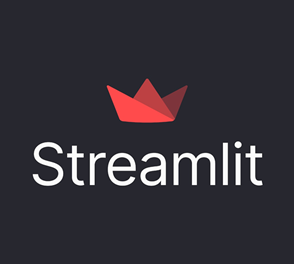

Streamlit is an open-source tool designed to help developers build interactive and visually rich web applications rapidly and with very little overhead, using the Python programming language.

In simple terms, if you have a data analysis workflow, a machine-learning model, or any Python script that you would like to share in a visual and interactive form, Streamlit allows you to transform that code into a functional web application with only a few lines of code.

**What is Streamlit used for?**

- Building visual interfaces for Python projects: you can display plots, buttons, forms, tables, and other interactive elements.
- Sharing interactive projects: users can interact with your data or models through the web without needing to know how to program.
- Rapid prototyping: instead of constructing an entire web page from scratch, Streamlit makes it possible to create working prototypes very quickly.


In [49]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('streamlit') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'streamlit'], check=True)

import streamlit
print(f'Streamlit {streamlit.__version__} is already installed.')


Streamlit 1.56.0 is already installed.


In [50]:
%%writefile primer_streamlit.py
import streamlit as st

# Application title
st.title('My First Streamlit Application')

# Introductory text
st.write('Welcome to my interactive application.')

# Add a button
if st.button('Click here'):
    st.write('The button has been clicked.')

# Add a text-input field
user_input = st.text_input('Enter your name and press Enter:', '')
if user_input:
    st.write(f'Hello, {user_input}.')

# Add a section for a simple calculator
st.write('### Simple Calculator')

# Numeric inputs
num1 = st.number_input('Enter the first number', value=0)
num2 = st.number_input('Enter the second number', value=0)

# Button for adding the numbers
if st.button('Add'):
    result = num1 + num2
    st.write(f'The result of the addition is: {result}')

# Numeric inputs
num3 = st.number_input('Enter the first number', value=0, key='third')
num4 = st.number_input('Enter the second number', value=0, key='fourth')

# Button for multiplying the numbers
if st.button('Multiply'):
    result = num3 * num4
    st.write(f'The result of the multiplication is: {result}')

# Closing message
st.write('You may include any kind of content in this application, including calculations, visualizations, and user interaction.')


Overwriting primer_streamlit.py


In [51]:
from pathlib import Path
import os
import re
import shutil
import signal
import subprocess
import sys
import time
import urllib.request

STREAMLIT_RUNTIME_DIR = Path.cwd() / '.streamlit_runtime'
STREAMLIT_RUNTIME_DIR.mkdir(exist_ok=True)


def _pid_path(name: str) -> Path:
    return STREAMLIT_RUNTIME_DIR / f'{name}.pid'


def _stop_pid(pid: int) -> bool:
    try:
        os.killpg(pid, signal.SIGTERM)
        return True
    except ProcessLookupError:
        return False


def stop_streamlit_app(name: str) -> None:
    stopped = False
    for suffix in ('cloudflared', 'streamlit'):
        pid_file = _pid_path(f'{name}_{suffix}')
        if not pid_file.exists():
            continue
        pid = int(pid_file.read_text().strip())
        stopped = _stop_pid(pid) or stopped
        pid_file.unlink(missing_ok=True)
    if stopped:
        print(f'Processes stopped for: {name}')
    else:
        print(f'No active processes were found for: {name}')


def ensure_cloudflared() -> Path:
    existing = shutil.which('cloudflared')
    if existing:
        return Path(existing)

    target = STREAMLIT_RUNTIME_DIR / 'cloudflared'
    if not target.exists():
        url = 'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64'
        print('Downloading cloudflared...')
        urllib.request.urlretrieve(url, target)
        target.chmod(target.stat().st_mode | 0o111)
    return target


def launch_streamlit_app(script_name: str, *, port: int, name: str, public_url: bool = True) -> None:
    script_path = Path(script_name).resolve()
    if not script_path.exists():
        raise FileNotFoundError(f'Could not find the file: {script_path}')

    stop_streamlit_app(name)

    app_dir = STREAMLIT_RUNTIME_DIR / name
    app_dir.mkdir(parents=True, exist_ok=True)
    streamlit_log = app_dir / 'streamlit.log'
    cloudflared_log = app_dir / 'cloudflared.log'

    with streamlit_log.open('w', encoding='utf-8') as handle:
        proc = subprocess.Popen(
            [
                sys.executable,
                '-m',
                'streamlit',
                'run',
                str(script_path),
                '--server.headless=true',
                f'--server.port={port}',
            ],
            cwd=script_path.parent,
            stdout=handle,
            stderr=subprocess.STDOUT,
            start_new_session=True,
        )
    _pid_path(f'{name}_streamlit').write_text(str(proc.pid))

    time.sleep(4)
    local_url = f'http://127.0.0.1:{port}'
    print(f'Local application available at: {local_url}')
    print(f'Streamlit log: {streamlit_log}')

    if not public_url:
        return

    try:
        cloudflared = ensure_cloudflared()
    except Exception as exc:
        print(f'Could not prepare cloudflared: {exc}')
        return

    with cloudflared_log.open('w', encoding='utf-8') as handle:
        tunnel = subprocess.Popen(
            [str(cloudflared), 'tunnel', '--url', local_url],
            cwd=script_path.parent,
            stdout=handle,
            stderr=subprocess.STDOUT,
            start_new_session=True,
        )
    _pid_path(f'{name}_cloudflared').write_text(str(tunnel.pid))

    public_match = None
    for _ in range(20):
        time.sleep(1)
        log_text = cloudflared_log.read_text(encoding='utf-8', errors='ignore')
        match = re.search(r'https://[-a-zA-Z0-9.]+trycloudflare\.com\S*', log_text)
        if match:
            public_match = match.group(0)
            break

    if public_match:
        print(f'Public application available at: {public_match}')
    else:
        print(f'The public URL is not available yet. Inspect: {cloudflared_log}')


In [52]:
launch_streamlit_app("primer_streamlit.py", port=8501, name="primer_streamlit", public_url=True)


No active processes were found for: primer_streamlit


Local application available at: http://127.0.0.1:8501
Streamlit log: /home/mitin/code/ml-theory/workshops/04-data-processing/.streamlit_runtime/primer_streamlit/streamlit.log
Public application available at: https://carrier-behavioral-sitting-spelling.trycloudflare.com


In [53]:
stop_streamlit_app("primer_streamlit")


Processes stopped for: primer_streamlit


In [54]:
%%writefile segundo_streamlit.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the California Housing data
housing = fetch_california_housing(as_frame=True).frame

# Application title
st.title('Data Exploration: California Housing')

# Introductory description
st.write("""
### Welcome
This interactive application allows the California Housing dataset to be explored.
You may:
1. View the first records.
2. Inspect general information about the dataset.
3. Generate dynamic plots.
""")

# Section for data exploration
st.sidebar.header('Data Exploration')

# Dynamically display the first rows
if st.sidebar.checkbox('Show first rows'):
    n_rows = st.sidebar.slider('Number of rows to display:', 1, 50, 5)
    st.write(f'### First {n_rows} rows of the dataset')
    st.write(housing.head(n_rows))

# Display dataset information
import io

if st.sidebar.checkbox('Show dataset information'):
    st.write('### Dataset Information')

    # Capture the output of info() in a buffer
    buffer = io.StringIO()
    housing.info(buf=buffer)

    # Convert the buffer contents into text
    info_text = buffer.getvalue()
    st.text(info_text)

# Descriptive statistics
if st.sidebar.checkbox('Show descriptive statistics'):
    st.write('### Descriptive Statistics')
    st.write(housing.describe())

# Section for dynamic plots
st.sidebar.header('Dynamic Plots')

# Select the variables to plot
x_var = st.sidebar.selectbox('Select the X variable:', housing.columns)
y_var = st.sidebar.selectbox('Select the Y variable:', housing.columns)

# Plot type
chart_type = st.sidebar.radio(
    'Select the plot type:',
    ('Scatter', 'Histogram', 'Boxplot')
)

# Display the plot
st.write('### Plots')
if chart_type == 'Scatter':
    st.write(f'#### Scatter plot: {x_var} vs {y_var}')
    fig, ax = plt.subplots()
    sns.scatterplot(data=housing, x=x_var, y=y_var, ax=ax)
    st.pyplot(fig)
elif chart_type == 'Histogram':
    st.write(f'#### Histogram of {x_var}')
    fig, ax = plt.subplots()
    sns.histplot(housing[x_var], bins=30, kde=True, ax=ax)
    st.pyplot(fig)
elif chart_type == 'Boxplot':
    st.write(f'#### Boxplot of {y_var} by {x_var}')
    fig, ax = plt.subplots()
    sns.boxplot(data=housing, x=x_var, y=y_var, ax=ax)
    st.pyplot(fig)

# Closing message
st.write('Use the sidebar to explore additional options.')


Overwriting segundo_streamlit.py


In [55]:
launch_streamlit_app("segundo_streamlit.py", port=8502, name="segundo_streamlit", public_url=True)


No active processes were found for: segundo_streamlit
Local application available at: http://127.0.0.1:8502
Streamlit log: /home/mitin/code/ml-theory/workshops/04-data-processing/.streamlit_runtime/segundo_streamlit/streamlit.log
Public application available at: https://objects-washing-assumptions-birth.trycloudflare.com


In [56]:
stop_streamlit_app("segundo_streamlit")


Processes stopped for: segundo_streamlit
